<a href="https://colab.research.google.com/github/foyezfar/DevOps/blob/main/Multiclass_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import zipfile
import os
import shutil
import glob

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
Zip_ref = zipfile.ZipFile("/content/drive/MyDrive/Data.zip","r")
Zip_ref.extractall("/tmp")
Zip_ref.close()

In [5]:
base_dir ="/tmp/Data/train"

In [6]:
import os
print(os.listdir("/tmp/Data/train"))

['OSTRICH', 'COCKATOO', 'CROW', 'PEACOCK', 'EMU', 'WOOD DUCK']


In [7]:
import tensorflow as tf
import numpy as np

In [8]:
import cv2
import random as rn
from tqdm import tqdm
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

In [9]:
IMAGE_SIZE=224
BATCH_SIZE=32

#pre=processing
train_datagen=tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1
    )

test_datagen=tf.keras.preprocessing.image.ImageDataGenerator(
     rescale=1./255,
     validation_split=0.1
)

train_datagen=train_datagen.flow_from_directory(
    base_dir,
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    subset='training'
)

test_datagen=test_datagen.flow_from_directory(
    base_dir,
    target_size=(IMAGE_SIZE,IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    subset='validation'
)

Found 923 images belonging to 6 classes.
Found 100 images belonging to 6 classes.


In [10]:
cnn=tf.keras.Sequential()
cnn.add(tf.keras.layers.Conv2D(filters=64,padding='same',strides=2,kernel_size=3,activation='relu',input_shape=(224,224,3)))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=32,padding='same',strides=2,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2,strides=2))

cnn.add(tf.keras.layers.Conv2D(filters=32,padding='same',strides=2,kernel_size=3,activation='relu'))
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2))

cnn.add(tf.keras.layers.Flatten())
cnn.add(tf.keras.layers.Dense(6,activation='softmax'))

In [11]:
cnn.compile(optimizer=tf.keras.optimizers.Adam(),loss='categorical_crossentropy',metrics=['accuracy'])

In [12]:
history = cnn.fit(train_datagen,epochs=50,validation_data=test_datagen)

Epoch 1/50
29/29 [==============================] - 25s 819ms/step - loss: 1.7276 - accuracy: 0.2600 - val_loss: 1.5906 - val_accuracy: 0.4000
Epoch 2/50
29/29 [==============================] - 24s 827ms/step - loss: 1.3613 - accuracy: 0.5352 - val_loss: 1.1515 - val_accuracy: 0.5300
Epoch 3/50
29/29 [==============================] - 24s 830ms/step - loss: 0.9779 - accuracy: 0.6327 - val_loss: 0.9511 - val_accuracy: 0.6500
Epoch 4/50
29/29 [==============================] - 24s 816ms/step - loss: 0.8808 - accuracy: 0.6663 - val_loss: 0.8929 - val_accuracy: 0.6700
Epoch 5/50
29/29 [==============================] - 24s 813ms/step - loss: 0.7683 - accuracy: 0.7281 - val_loss: 0.7990 - val_accuracy: 0.7400
Epoch 6/50
29/29 [==============================] - 24s 817ms/step - loss: 0.7111 - accuracy: 0.7335 - val_loss: 0.7371 - val_accuracy: 0.7700
Epoch 7/50
29/29 [==============================] - 24s 825ms/step - loss: 0.6229 - accuracy: 0.7790 - val_loss: 0.7470 - val_accuracy: 0.7300

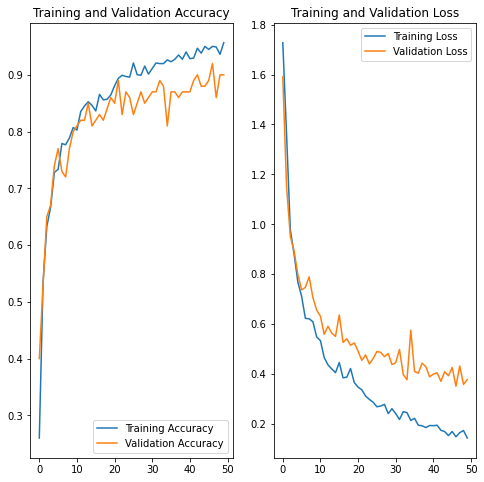

In [13]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(50)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [14]:
cnn.save('BC.h5')

In [15]:
lab = train_datagen.class_indices
print(lab)
lab={k:v for v,k in lab.items()}
print(lab)

{'COCKATOO': 0, 'CROW': 1, 'EMU': 2, 'OSTRICH': 3, 'PEACOCK': 4, 'WOOD DUCK': 5}
{0: 'COCKATOO', 1: 'CROW', 2: 'EMU', 3: 'OSTRICH', 4: 'PEACOCK', 5: 'WOOD DUCK'}


In [16]:
from keras.layers import Input, Lambda, Dense, Flatten
from keras.models import Model
from keras.preprocessing import image
from keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
import numpy as np
from glob import glob
import matplotlib.pyplot as plt

In [17]:
from keras.models import load_model

model1 = load_model('/content/BC.h5',compile=False)  

In [18]:

def output(location):
    img=load_img(location,target_size=(224,224,3))
    img=img_to_array(img)
    img=img/255
    img=np.expand_dims(img,[0])
    answer=model1.predict(img)
    y_class = answer.argmax(axis=-1)
    y = " ".join(str(x) for x in y_class)
    y = int(y)
    res = lab[y]
    return res

In [19]:
import numpy as np

from google.colab import files
from keras.preprocessing import image

uploaded=files.upload()

Saving 007.jpg to 007.jpg


In [20]:
import keras
import tensorflow as tf

#image = keras.utils.load_img('path_to_image', target_size=(img_size, img_size))

for fn in uploaded.keys():
 # predicting images
  path='/content/' + fn
  img=keras.utils.load_img(path, target_size=(120, 120))

  x=keras.utils.img_to_array(img)
  test_img=np.expand_dims(x, axis=0)

  result = cnn.predict(test_img)
  pred = np.argmax(result) # get the index of max value

  print(pred)
  
  
  


ValueError: ignored

In [21]:
import tensorflow as tf
import keras as k
print(tf.__version__)
print(k.__version__)

2.9.2
2.9.0
